## STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree

**Interpretation:**
* pandas → data handling
* numpy → numerical operations
* matplotlib → visualization
* sklearn → machine learning model (Decision Tree)
* plot_tree helps us visualize how the decision tree makes decisions

## STEP 2: LOAD DATASET

In [2]:
df = pd.read_csv("bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


**Interpretation:**
* Dataset contains customer details (age, job, balance, etc.)
* Target variable:
    * y → whether customer subscribed (yes/no)

## STEP 3: BASIC EXPLORATORY DATA ANALYSIS

### 3.1 Dataset Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


**Interpretation:**
* Shows:
    * Data types (categorical & numerical)
    * No. of rows (~45,000)
* Many columns are categorical

### 3.2 Check Missing Values

In [4]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

**Interpretation:**
* There are no null values

### 3.3 Check Target Distribution

In [5]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

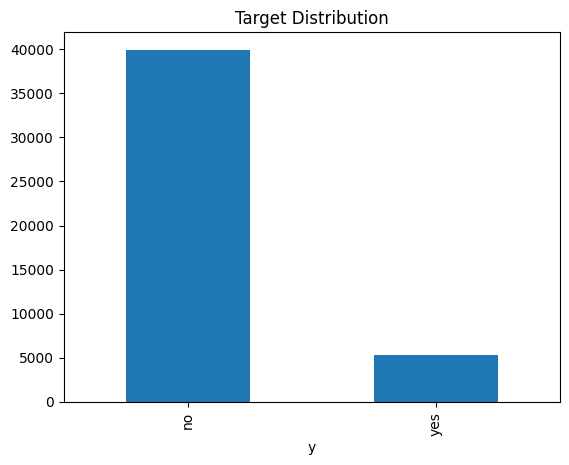

In [6]:
df['y'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.show()

**Interpretation:**
* More “no” than “yes”
* Dataset is imbalanced

## STEP 4: DATA CLEANING

### 4.1 Remove duplicates

In [7]:
df = df.drop_duplicates()

**Interpretation:**
* Removes repeated records → improves model accuracy

### 4.2 Encode categorical variables

In [8]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

**Interpretation:**
* Machine learning needs numbers
* Converts:
    * yes/no → 1/0
    * job types → numeric labels

## STEP 5: DEFINE FEATURES & TARGET

In [9]:
X = df.drop('y', axis=1)
y = df['y']

**Interpretation:**
* X → input variables
* y → output (target)

## STEP 6: TRAIN-TEST SPLIT

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Interpretation:**
* 80% training, 20% testing
* Ensures fair model evaluation

## STEP 7: BUILD DECISION TREE MODEL

In [11]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

**Interpretation:**
* Model learns patterns:
    * Age
    * Job
    * Balance, etc.
* To predict subscription

## STEP 8: MAKE PREDICTIONS

In [12]:
y_pred = model.predict(X_test)

**Interpretation:**
* Model predicts whether customer will subscribe

## STEP 9: EVALUATE MODEL

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8740462235983634


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7952
           1       0.48      0.49      0.49      1091

    accuracy                           0.87      9043
   macro avg       0.70      0.71      0.71      9043
weighted avg       0.88      0.87      0.87      9043



**Interpretation:**
* Accuracy → overall correctness
* Precision & Recall:
    * Important for imbalanced data
* Helps judge model performance

## STEP 10: PREDICT ON TEST DATA

In [15]:
print("Predictions:", y_pred[:10])
print("Actual:", y_test.values[:10])

Predictions: [0 0 0 0 0 0 1 0 0 1]
Actual: [0 0 0 0 0 0 0 0 0 0]


**Interpretation:**
* Compares:
    * Model prediction vs actual value
* Meaning:
    * 0 = No (Not subscribed)
    * 1 = Yes (Subscribed)

## STEP 11: PREDICT FOR NEW CUSTOMER

In [16]:
new_customer = X.iloc[0:1]   # take one sample row
prediction = model.predict(new_customer)
print("Prediction:", prediction)
if prediction[0] == 1:
    print("Customer will purchase the product")
else:
    print("Customer will NOT purchase the product")

Prediction: [0]
Customer will NOT purchase the product


**Interpretation:**
* Output:
    * 0 → Customer will NOT purchase
    * 1 → Customer WILL purchase